In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from volume_density_DESI import ang_to_vol_density, load_z

DATA_DIR = Path("****")# Path settings

## Box number density

In [2]:
csv_path = DATA_DIR / "nz_box_gfibcut.csv"#compute_nz_box.py
df = pd.read_csv(csv_path)

z1   = df["z"].values
nV_L_cut = df["nV_LOP[(h/Mpc)^3]"].values
nV_V_cut = df["nV_VLO[(h/Mpc)^3]"].values
f_cut_LOP = df["f_cut_LOP"].values
f_cut_VLO = df["f_cut_VLO"].values

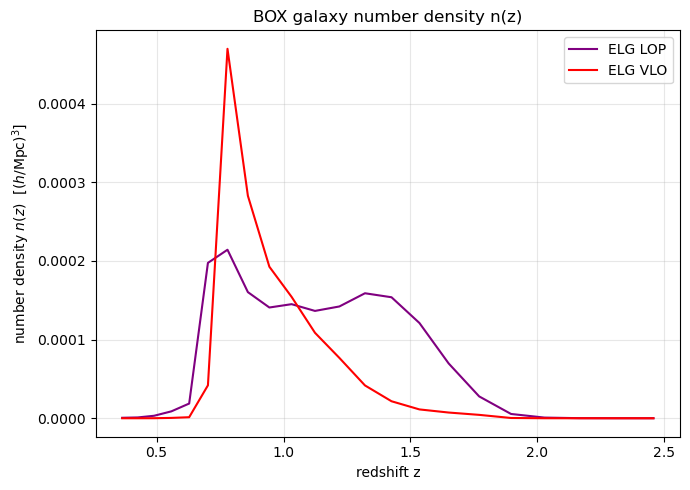

In [3]:
plt.figure(figsize=(7,5))

plt.plot(z1, nV_L_cut, color="purple", label="ELG LOP")

plt.plot(z1, nV_V_cut, color="red", label="ELG VLO")

plt.xlabel("redshift z")
plt.ylabel(r"number density $n(z)$  [$(h/{\rm Mpc})^3$]")
plt.title("BOX galaxy number density n(z)")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

## Box vs DESI

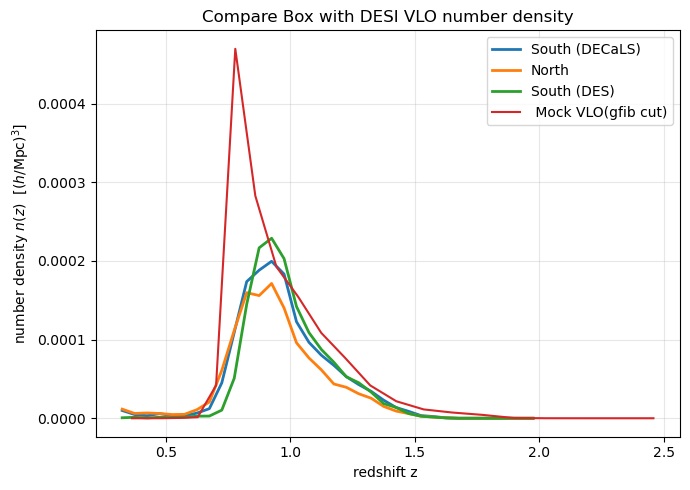

In [5]:
z = load_z(DATA_DIR)
mask_desi = (z >= 0.3)
mask_mock = (z1 >= 0.3)
vlo_cols   = ["ELG_VLO_SOUTH_DECALS", "ELG_VLO_NORTH", "ELG_VLO_SOUTH_DES"]
vlo_labels = ["South (DECaLS)", "North", "South (DES)"]
plt.figure(figsize=(7,5))

for col, lab in zip(vlo_cols, vlo_labels):
    n_vol = ang_to_vol_density(col, DATA_DIR)           
    plt.plot(z[mask_desi],                 
             n_vol[mask_desi],
             lw=2, label=lab)

plt.plot(z1[mask_mock], nV_V_cut[mask_mock],
          label=" Mock VLO(gfib cut)")

plt.xlabel("redshift z ")
plt.ylabel(r"number density $n(z)$  [$(h/{\rm Mpc})^3$]")
plt.title("Compare Box with DESI VLO number density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

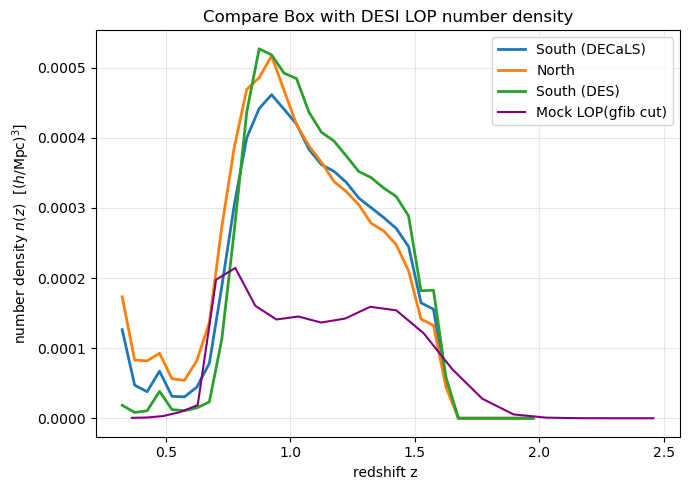

In [6]:
lop_cols   = ["ELG_LOP_SOUTH_DECALS", "ELG_LOP_NORTH", "ELG_LOP_SOUTH_DES"]
lop_labels = ["South (DECaLS)", "North", "South (DES)"]
plt.figure(figsize=(7,5))

for col, lab in zip(lop_cols, lop_labels):
    n_vol = ang_to_vol_density(col, DATA_DIR)            
    plt.plot(z[mask_desi],                
             n_vol[mask_desi],
             lw=2, label=lab)

plt.plot(z1[mask_mock], nV_L_cut[mask_mock],
          color="purple", label="Mock LOP(gfib cut)")

plt.xlabel("redshift z ")
plt.ylabel(r"number density $n(z)$  [$(h/{\rm Mpc})^3$]")
plt.title("Compare Box with DESI LOP number density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()